# Does a transformer do Bayesian inference?

A from-scratch micro-GPT trained on a **bijection task**. We test whether, when predicting each output, the model behaves like the Bayesian-optimal predictor: **uniform over the outputs not yet used.**

In [2]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np
random.seed(42)

## Experiment overview

The central question is: **does a transformer trained on a structured task learn to perform Bayesian inference, or does it approximate it?**

The experiment has three stages:

1. **Task design** : train on bijection sequences where the only learnable signal is that outputs are never reused.
2. **Training** : a micro-GPT (~3.7k parameters) is trained from scratch using a custom autograd engine and Adam optimiser. No PyTorch.
3. **Evaluation** : at inference time we compare the model's output distribution to the true Bayesian posterior and inspect the attention head to understand *how* the model does it.

## The task

Each document is a random **bijection** (permutation) over `V` symbols, written as `x → y` pairs separated by `SEP` and wrapped in `BOS`:

`BOS  x0 y0 SEP  x1 y1 SEP  …  BOS`

The mapping is random every time, so nothing about a specific `x → y` can be memorised. The only usable signal is that **outputs never repeat** : so the best guess for the next output is uniform over whatever hasn't been used yet.

In [ ]:
def generate_bijection_sequence(V=5, shuffle_pairs=True): #shuffle pair to rwmove any bias in the order of pairs

    inputs = list(range(V))

    outputs = list(range(V))
    random.shuffle(outputs)

    mapping = dict(zip(inputs, outputs))

    pair_order = list(mapping.keys())

    if shuffle_pairs:
        random.shuffle(pair_order)

    SEP = 2 * V

    sequence = []

    for x in pair_order:

        sequence.append(x)
        sequence.append(V + mapping[x])
        sequence.append(SEP)

    return mapping, sequence

The cell below prints a small example so we can see the format concretely.

With `V=5` and `shuffle_pairs=False` the mapping is fixed and pairs appear in input order `0, 1, 2, …`. With `shuffle_pairs=True` (used during training) the pairs are reordered so the model cannot exploit position to predict the next output : it *must* track which outputs have already appeared.

In [18]:
mapping, sequence = generate_bijection_sequence(
    V=5,
    shuffle_pairs=False
)
print(mapping)
print(sequence)

{0: 4, 1: 1, 2: 2, 3: 3, 4: 0}
[0, 9, 10, 1, 6, 10, 2, 7, 10, 3, 8, 10, 4, 5, 10]


## A tiny autograd engine

`Value` is a scalar node that stores its children and their local derivatives. The forward pass builds the computation graph; `backward()` walks it in reverse and applies the chain rule. The entire transformer below is built from these scalars no PyTorch.

In [13]:
# Let there be Autograd to recursively apply the chain rule through a computation graph
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads') # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # scalar value of this node calculated during forward pass
        self.grad = 0                   # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children       # children of this node in the computation graph
        self._local_grads = local_grads # local derivative of this node w.r.t. its children

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad


The `Value` class implements the following differentiable operations:

| Operation | Forward | Local gradient |
| --------- | ------- | -------------- |
| `+`, `-`, `*`, `/` | standard arithmetic | 1 / other.data / self.data … |
| `**` (power) | `data**n` | `n * data**(n-1)` |
| `log` | `ln(data)` | `1 / data` |
| `exp` | `e**data` | `e**data` |
| `relu` | `max(0, data)` | `1 if data > 0 else 0` |

`backward()` performs a **topological sort** of the computation graph and then walks it in reverse, accumulating gradients via the chain rule. This is identical in spirit to PyTorch's autograd : just scalar instead of tensor.

## Model configuration

A deliberately tiny GPT: **1 layer, 1 head, `n_embd = 16`** (~3.7k parameters). Small enough to train from scratch in pure Python and to inspect the attention head by hand. The vocabulary is the `V` inputs, `V` outputs, plus `SEP` and `BOS`.

In [19]:
V = 5
SEP = 2 * V
BOS = SEP + 1   
vocab_size = BOS + 1
print(vocab_size)
# Initialize the parameters, to store the knowledge of the model
n_layer = 1     # depth of the transformer neural network (number of layers)
n_embd = 16     # width of the network (embedding dimension)
# block_size = 16 # maximum context length of the attention window (note: the longest name is 15 characters)
block_size = 3 * V + 2
n_head = 1      # number of attention heads
head_dim = n_embd // n_head # derived dimension of each head
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
params = [p for mat in state_dict.values() for row in mat for p in row] # flatten params into a single list[Value]
print(f"num params: {len(params)}")

12
num params: 3728


### Why these hyperparameters?

- **`V = 5`** : small enough that the full bijection fits in a single context window and attention patterns can be visualised.
- **`n_layer = 1`, `n_head = 1`** : the task requires only one kind of reasoning (output elimination), so one head is enough. Using a single head also makes it possible to read the attention matrix directly.
- **`n_embd = 16`** : the smallest embedding that gives the model enough capacity to represent the bijection structure.



## The forward pass

A standard GPT block: token + position embeddings → RMSNorm → **causal self-attention** → MLP, with residual connections, then an unembedding (`lm_head`) to vocabulary logits. The `analysis` dict just records intermediates (queries, keys, attention weights, …) so we can inspect them later.

In [ ]:
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

def gpt(token_id, pos_id, keys, values, analysis):
    tok_emb = state_dict['wte'][token_id] # token embedding
    pos_emb = state_dict['wpe'][pos_id] # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)] # joint token and position embedding
    x = rmsnorm(x) # note: not redundant due to backward pass via the residual connection

    for li in range(n_layer):
        # 1) Multi-head Attention block
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        analysis["queries"].append(q)
        analysis["keys"].append(k)
        analysis["values"].append(v)
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            analysis["attn_logits"].append(attn_logits)
            attn_weights = softmax(attn_logits)
            analysis["attn_weights"].append(attn_weights)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]
        analysis["residuals"].append(x)
        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x] 
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])
    return logits

## Training

A **fresh random bijection every step** (the model never sees the same example twice), with `shuffle_pairs=True` so pair order is randomised : this stops the model from cheating with position and forces it to track outputs by content. Only the output-token predictions are supervised. The loss is noisy for exactly this reason.

In [ ]:
# Let there be Adam, the blessed optimizer and its buffers
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params) # first moment buffer
v = [0.0] * len(params) # second moment buffer
# Repeat in sequence
num_steps = 5000 # number of training steps
for step in range(num_steps):
    # Take single document, tokenize it, surround it with BOS special token on both sides
    # doc = docs[step % len(docs)]
    _, doc = generate_bijection_sequence(  #every time we generate a new bijection sequence, we get a new document to train on. every training example is sampled from a fresh random bijection.
    V=V,
    shuffle_pairs=True
)
    tokens = [BOS] + doc + [BOS]
    n = min(block_size, len(tokens) - 1)
    # Forward the token sequence through the model, building up the computation graph all the way to the loss
    analysis = {
    "queries": [],
    "keys": [],
    "values": [],
    "attn_logits": [],
    "attn_weights": [],
    "residuals": []
}
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id = tokens[pos_id]
        target_id = tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values, analysis)
        probs = softmax(logits)
        # Only supervise output predictions
        if V <= target_id < 2 * V: #5-9, the output tokens
            loss_t = -probs[target_id].log()
            losses.append(loss_t)
    loss = sum(losses) / len(losses)    
    # Backward the loss, calculating the gradients with respect to all model parameters
    loss.backward()
    # Adam optimizer update: update the model parameters based on the corresponding gradients
    lr_t = learning_rate * (1 - step / num_steps) # linear learning rate decay
    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
        m_hat = m[i] / (1 - beta1 ** (step + 1))
        v_hat = v[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    #print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}", end='\r')
    if step % 250 == 0:
        print(step, loss.data)

0 1.2325509555788203
250 1.1380431166375669
500 1.0956714371002925
750 1.2419524299385818
1000 1.0538018554162865
1250 0.9782779995668778
1500 1.341972080491259
1750 1.1524702109891838
2000 0.9115909181509368
2250 0.7685258885138117
2500 0.819981588048182
2750 1.0374143000456804
3000 1.2024747987790536
3250 1.254635346050503
3500 1.2620103233157722
3750 0.9594711371353304
4000 0.7898002397041178
4250 0.9152502856150315
4500 0.8948319189912048
4750 0.925712236047645


### Training loss

The loss is **noisy** by design: every step draws a fresh random bijection, so the model rarely sees the same example twice. The important thing is that the **trend** is downward : the model is learning to concentrate probability on unused outputs.

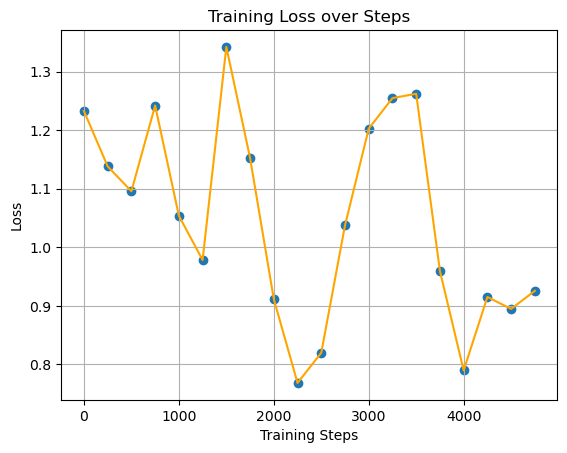

In [67]:
l=np.array([1.2325509555788203,1.1380431166375669, 1.0956714371002925, 1.2419524299385818, 1.0538018554162865, 0.9782779995668778, 1.341972080491259, 1.1524702109891838, 0.9115909181509368, 0.7685258885138117, 0.819981588048182, 1.0374143000456804, 1.2024747987790536, 1.254635346050503, 1.2620103233157722, 0.9594711371353304, 0.7898002397041178, 0.9152502856150315, 0.8948319189912048, 0.925712236047645])
x_axis=np.array([0,250,500,750,1000,1250,1500,1750,2000,2250,2500,2750,3000,3250,3500,3750,4000,4250,4500,4750])
plt.scatter(x_axis, l)
plt.plot(x_axis, l,color='orange')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.grid()
plt.show()

## Inference: does the model eliminate used outputs?

We feed one fixed sequence and, at each input `xi`, read the model's distribution over outputs. We compare it against the **Bayesian posterior** (uniform over the outputs not yet used) using entropy, KL.

In [ ]:
def bayes_posterior(remaining_outputs, V):
    posterior = np.zeros(V)
    p = 1.0 / len(remaining_outputs)
    for y in remaining_outputs:
        posterior[y] = p
    return posterior
def kl(p, q):
    eps = 1e-10
    p = p + eps
    q = q + eps
    p /= p.sum()
    q /= q.sum()
    return np.sum(p * np.log2(p / q))
tokens = [BOS] + sequence + [BOS]
analysis = {
    "queries": [],
    "keys": [],
    "values": [],
    "attn_logits": [],
    "attn_weights": [],
    "residuals": [],
    "entropy": [],
    "bayes_entropy": [],
    "prediction_probs": [],
    "bayes_probs": [],
    "kl": [],}
keys = [[] for _ in range(n_layer)]
values = [[] for _ in range(n_layer)]
used_outputs = set()
for pos_id in range(len(tokens)-1):
    token_id = tokens[pos_id]
    logits = gpt(
        token_id,
        pos_id,
        keys,
        values,
        analysis
    )
    probs = softmax(logits)
    # Only analyse predictions made after x tokens
    if token_id < V:
        output_probs = np.array(
            [float(probs[V+i].data) for i in range(V)]
        )
        output_probs /= output_probs.sum()
        prediction = np.argmax(output_probs)
        remaining = sorted(
            set(range(V)) - used_outputs
        )
        bayes = bayes_posterior(
            remaining,
            V
        )
        transformer_entropy = -np.sum(
            output_probs*np.log2(output_probs+1e-12)
        )
        bayes_entropy = -np.sum(
            bayes*np.log2(bayes+1e-12)
        )
        kl_div = kl(bayes, output_probs)
        analysis["prediction_probs"].append(output_probs)
        analysis["bayes_probs"].append(bayes)
        analysis["entropy"].append(transformer_entropy)
        analysis["bayes_entropy"].append(bayes_entropy)
        analysis["kl"].append(kl_div)
        print("="*70)
        print(f"Input              : x{token_id}")
        print(f"Ground Truth       : y{mapping[token_id]}")
        print(f"Prediction         : y{prediction}")
        print(f"\nRemaining outputs  : {remaining}")
        print(f"\nTransformer entropy : {transformer_entropy:.3f}")
        print(f"Bayesian entropy    : {bayes_entropy:.3f}")
        print(f"KL(Bayes||Model)    : {kl_div:.4f}")
        print("\nOutput probabilities")
        ranking = sorted(
            [(i,p) for i,p in enumerate(output_probs)],
            key=lambda x:-x[1]
        )
        for output,p in ranking:
            marker = ""
            if output == mapping[token_id]:
                marker += " ✓"
            if output not in remaining:
                marker += " (used)"
            print(
                f"y{output}: "
                f"Model={p:.3f} "
                f"Bayes={bayes[output]:.3f}"
                f"{marker}"
            )
        used_outputs.add(
            mapping[token_id]
        )

Input              : x0
Ground Truth       : y4
Prediction         : y3

Remaining outputs  : [0, 1, 2, 3, 4]

Transformer entropy : 2.318
Bayesian entropy    : 2.322
KL(Bayes||Model)    : 0.0041

Output probabilities
y3: Model=0.218 Bayes=0.200
y0: Model=0.207 Bayes=0.200
y1: Model=0.207 Bayes=0.200
y2: Model=0.194 Bayes=0.200
y4: Model=0.175 Bayes=0.200 ✓
Input              : x1
Ground Truth       : y1
Prediction         : y1

Remaining outputs  : [0, 1, 2, 3]

Transformer entropy : 2.005
Bayesian entropy    : 2.000
KL(Bayes||Model)    : 0.0037

Output probabilities
y1: Model=0.269 Bayes=0.250 ✓
y2: Model=0.259 Bayes=0.250
y0: Model=0.241 Bayes=0.250
y3: Model=0.231 Bayes=0.250
y4: Model=0.001 Bayes=0.000 (used)
Input              : x2
Ground Truth       : y2
Prediction         : y2

Remaining outputs  : [0, 2, 3]

Transformer entropy : 1.631
Bayesian entropy    : 1.585
KL(Bayes||Model)    : 0.0264

Output probabilities
y2: Model=0.368 Bayes=0.333 ✓
y0: Model=0.358 Bayes=0.333
y3: Mo

## Result 1: uncertainty collapses like Bayes

The model's prediction entropy should fall step-by-step as outputs get used up. Below it is plotted against the Bayesian entropy (`log2` of the number of remaining outputs) : the two curves should track the same staircase down to 0.

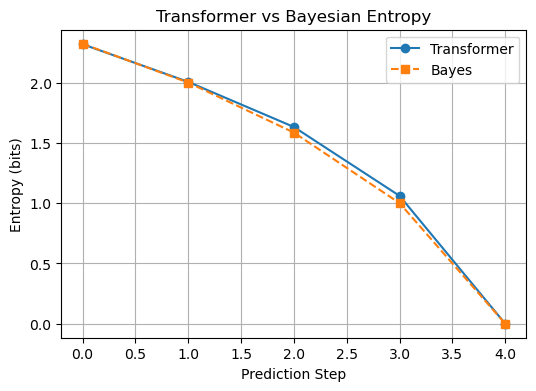

In [41]:
plt.figure(figsize=(6,4))

plt.plot(
    analysis["entropy"],
    'o-',
    label="Transformer"
)

plt.plot(
    analysis["bayes_entropy"],
    's--',
    label="Bayes"
)

plt.xlabel("Prediction Step")
plt.ylabel("Entropy (bits)")
plt.title("Transformer vs Bayesian Entropy")
plt.grid(True)
plt.legend()
plt.show()

## Result 2: distance from the posterior

`KL(Bayes || Model)` measures how far the model's output distribution sits from the true Bayesian posterior at each step. Near-zero means the model *is* the posterior.

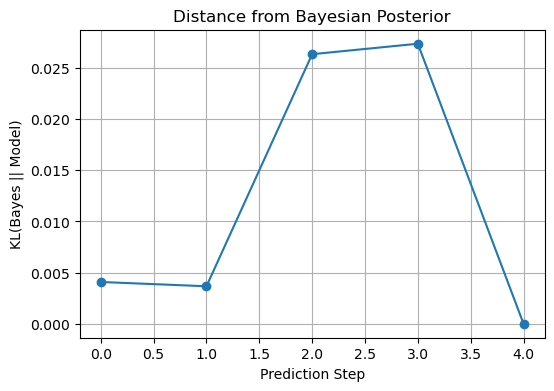

In [42]:
plt.figure(figsize=(6,4))

plt.plot(
    analysis["kl"],
    'o-'
)

plt.xlabel("Prediction Step")
plt.ylabel("KL(Bayes || Model)")

plt.title("Distance from Bayesian Posterior")

plt.grid(True)
plt.show()

## Opening up the attention head

The plots so far show the model's **output** is Bayesian. The next three look **inside** the single attention head to see *how* it does it.

### Causal attention matrix

Every query (row) can only attend to keys at or before it, so the map must be **lower-triangular**. Bright cells early on sit on `BOS` a normal "attention sink" when there's little context yet.

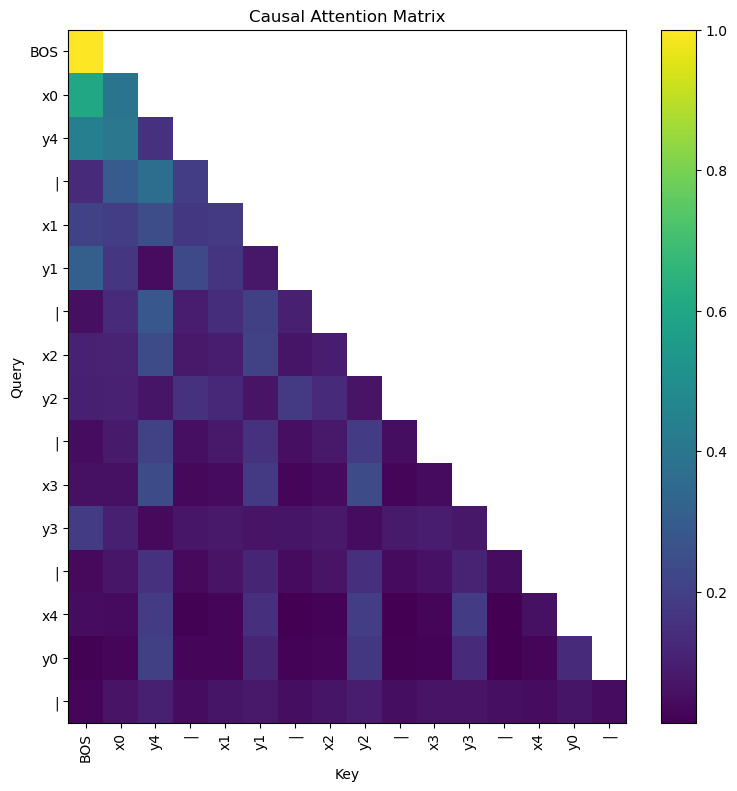

In [ ]:
tokens_str = []

for t in tokens:
    if t == BOS:
        tokens_str.append("BOS")
    elif t == SEP:
        tokens_str.append("|")
    elif t < V:
        tokens_str.append(f"x{t}")
    else:
        tokens_str.append(f"y{t-V}")
tokens_str = tokens_str[:-1]
N = len(analysis["attn_weights"])

A = np.full((N, N), np.nan)

for i,row in enumerate(analysis["attn_weights"]):
    for j,w in enumerate(row):
        A[i,j] = float(w.data)

plt.figure(figsize=(9,9))
plt.imshow(A, cmap="viridis", aspect="auto")

plt.xticks(range(N), tokens_str, rotation=90)
plt.yticks(range(N), tokens_str)

plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Causal Attention Matrix")

plt.colorbar()
plt.show()
plt.show()

### Where does each input attend: inputs or outputs?

For every `xi` query we sum how much attention lands on previous **input (x)** tokens vs previous **output (y)** tokens. To eliminate used outputs the head has to read the **y** tokens, so attention-to-`y` should climb as more outputs pile up.

*(The two lines don't add to 1, the remainder is attention on `BOS`/`SEP`.)*

In [ ]:
x_attention = []
y_attention = []
labels = []
for i,row in enumerate(analysis["attn_weights"]):
    query = tokens[i]
    if query >= V or query in (SEP, BOS): #skip attention analysis for non-x queries and special tokens
        continue
    attn = np.array([float(w.data) for w in row])
    x_sum = 0
    y_sum = 0
    for j in range(len(row)):
        token = tokens[j]
        if token < V:
            x_sum += attn[j]
        elif V <= token < 2*V:
            y_sum += attn[j]
    x_attention.append(x_sum)
    y_attention.append(y_sum)
    labels.append(f"x{query}")

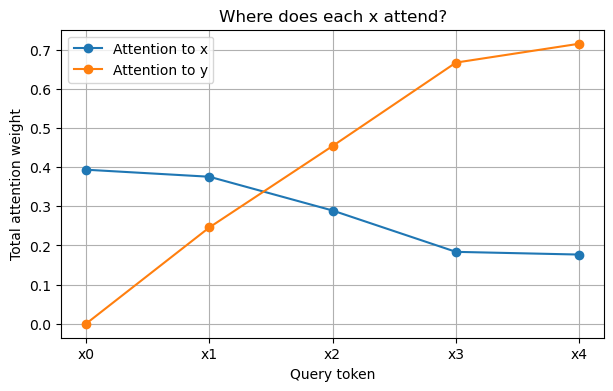

In [50]:
plt.figure(figsize=(7,4))

plt.plot(labels, x_attention, 'o-', label="Attention to x")
plt.plot(labels, y_attention, 'o-', label="Attention to y")

plt.ylabel("Total attention weight")
plt.xlabel("Query token")
plt.title("Where does each x attend?")

plt.legend()
plt.grid(True)
plt.show()

attention to y climbs as more outputs are consumed.

### Single step attention when predicting after x3

At this point outputs `y4, y1, y2` have already been used. If the head is doing elimination, it should attend to exactly those three previous output tokens (and little else).

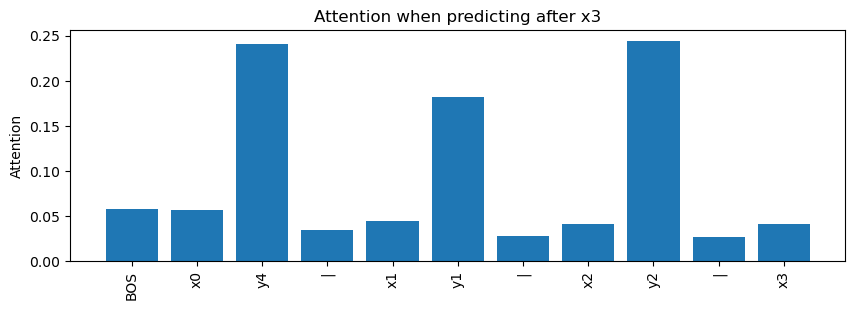

In [51]:
query_index = tokens.index(3)   # x3

row = np.array(
    [float(w.data) for w in analysis["attn_weights"][query_index]]
)

plt.figure(figsize=(10,3))

plt.bar(range(len(row)), row)

plt.xticks(range(len(row)),
           tokens_str[:len(row)],
           rotation=90)

plt.ylabel("Attention")

plt.title("Attention when predicting after x3")

plt.show()

# Concluding Remarks

For the bijection task:

1. The Bayesian posterior is completely determined by the set of outputs that have already been observed (equivalently, the remaining feasible outputs).

2. Therefore, the set of used outputs is a sufficient statistic for inference.

3. The transformer's attention progressively retrieves information about these previously observed outputs.

4. The resulting output distribution closely matches the analytic Bayesian posterior, suggesting that Bayesian-like hypothesis elimination emerges in this minimal transformer.

5. A 3,728-parameter, 1-layer, 1-head transformer approximates the Bayesian-optimal predictor on a bijection task

6. KL<0.03 at each step

7. Entropy decreases

Supports the hypothesis that transformers perform implicit bayesian computation.